In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import json

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
N_EPOCHS      = 50
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
TRAIN_SUBSET  = 1500
TEST_SUBSET   = 500

NOISE_LEVELS = [0.0, 0.005, 0.05, 0.10]

SAVE_DIR = "./mnist_classical_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
class ClassicalAlexNet(nn.Module):
    def __init__(self, n_classes=10):
        super(ClassicalAlexNet, self).__init__()
        alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        self.features = alexnet.features
        for param in self.features.parameters():
            param.requires_grad = False
        self.avgpool = alexnet.avgpool
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(9216, 512)
        self.bn1    = nn.BatchNorm1d(512)
        self.act1   = nn.LeakyReLU(0.1)
        self.dense2 = nn.Linear(512, 128)
        self.bn2    = nn.BatchNorm1d(128)
        self.act2   = nn.LeakyReLU(0.1)
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.act1(self.bn1(self.dense1(x)))
        x = self.act2(self.bn2(self.dense2(x)))
        x = self.classifier(x)
        return x

In [5]:
class AddGaussianNoise:
    def __init__(self, std=0.0):
        self.std = std
    def __call__(self, tensor):
        if self.std == 0.0:
            return tensor
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std, 0.0, 1.0)

In [6]:
def build_loaders_mnist(noise_std=0.0):
    noise_step = [AddGaussianNoise(std=noise_std)] if noise_std > 0.0 else []
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ] + noise_step)
    train_full = datasets.MNIST(root="./data", train=True,  download=True, transform=tf)
    test_full  = datasets.MNIST(root="./data", train=False, download=True, transform=tf)
    train_loader = DataLoader(Subset(train_full, list(range(TRAIN_SUBSET))),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(Subset(test_full,  list(range(TEST_SUBSET))),
                              batch_size=BATCH_SIZE, shuffle=False)
    print(f"MNIST | noise={noise_std} | train={TRAIN_SUBSET} | test={TEST_SUBSET}")
    return train_loader, test_loader

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

def save_checkpoint(noise_std, epoch, model, optimizer, history):
    noise_tag = str(noise_std).replace(".", "_")
    path = os.path.join(SAVE_DIR, f"ckpt_noise{noise_tag}_epoch{epoch}.pth")
    torch.save({
        "epoch":                epoch,
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history":              history,
    }, path)
    json_path = os.path.join(SAVE_DIR, f"history_noise{noise_tag}.json")
    json_history = {k: v for k, v in history.items() if k != "cm"}
    with open(json_path, "w") as f:
        json.dump(json_history, f)
    print(f"  [Saved checkpoint: {path}]")

def load_latest_checkpoint(noise_std, model, optimizer):
    noise_tag = str(noise_std).replace(".", "_")
    files = [
        f for f in os.listdir(SAVE_DIR)
        if f.startswith(f"ckpt_noise{noise_tag}_epoch") and f.endswith(".pth")
    ]
    if not files:
        return 0, {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    latest = sorted(files, key=lambda x: int(x.split("_epoch")[1].replace(".pth", "")))[-1]
    path = os.path.join(SAVE_DIR, latest)
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"  [Resumed from checkpoint: {path}]")
    return checkpoint["epoch"], checkpoint["history"]

def save_final_results(results):
    for noise, history in results.items():
        noise_tag = str(noise).replace(".", "_")
        if "cm" in history:
            np.save(os.path.join(SAVE_DIR, f"cm_noise{noise_tag}.npy"), history["cm"])
    json_results = {}
    for noise, history in results.items():
        noise_tag = str(noise).replace(".", "_")
        json_results[noise_tag] = {k: v for k, v in history.items() if k != "cm"}
    with open(os.path.join(SAVE_DIR, "all_results.json"), "w") as f:
        json.dump(json_results, f)
    print(f"\n[All results saved to {SAVE_DIR}]")

In [8]:
def run_experiment_mnist(noise_std):
    print(f"\nMNIST Classical | noise={noise_std * 100:.1f}%")
    print("\n")
    train_loader, test_loader = build_loaders_mnist(noise_std=noise_std)
    model     = ClassicalAlexNet(n_classes=10).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    start_epoch, history = load_latest_checkpoint(noise_std, model, optimizer)
    if start_epoch > 0:
        print(f"  [Resuming from epoch {start_epoch + 1}]")
    for epoch in range(start_epoch + 1, N_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        te_loss, te_acc, preds, labels = evaluate(model, test_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        print(f"Epoch [{epoch}/{N_EPOCHS}] "
              f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}% | "
              f"Test Loss: {te_loss:.4f} | Test Acc: {te_acc*100:.2f}%")
        save_checkpoint(noise_std, epoch, model, optimizer, history)
    precision = precision_score(labels, preds, average="weighted", zero_division=0)
    recall    = recall_score(labels, preds, average="weighted", zero_division=0)
    f1        = f1_score(labels, preds, average="weighted", zero_division=0)
    cm        = confusion_matrix(labels, preds)
    history["precision"] = precision
    history["recall"]    = recall
    history["f1"]        = f1
    history["cm"]        = cm
    print(f"\nFinal Metrics | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    return history


In [9]:
results = {}
for noise in NOISE_LEVELS:
    results[noise] = run_experiment_mnist(noise)

save_final_results(results)
print("\nAll experiments complete.")


MNIST Classical | noise=0.0%




100%|██████████| 9.91M/9.91M [00:00<00:00, 37.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


MNIST | noise=0.0 | train=1500 | test=500
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 167MB/s]  


Epoch [1/50] Train Loss: 0.4635 | Train Acc: 91.40% | Test Loss: 0.1524 | Test Acc: 98.40%
  [Saved checkpoint: ./mnist_classical_checkpoints/ckpt_noise0_0_epoch1.pth]
Epoch [2/50] Train Loss: 0.0855 | Train Acc: 99.13% | Test Loss: 0.1034 | Test Acc: 97.20%
  [Saved checkpoint: ./mnist_classical_checkpoints/ckpt_noise0_0_epoch2.pth]
Epoch [3/50] Train Loss: 0.0318 | Train Acc: 99.80% | Test Loss: 0.0729 | Test Acc: 98.80%
  [Saved checkpoint: ./mnist_classical_checkpoints/ckpt_noise0_0_epoch3.pth]
Epoch [4/50] Train Loss: 0.0166 | Train Acc: 100.00% | Test Loss: 0.0636 | Test Acc: 98.20%
  [Saved checkpoint: ./mnist_classical_checkpoints/ckpt_noise0_0_epoch4.pth]
Epoch [5/50] Train Loss: 0.0090 | Train Acc: 100.00% | Test Loss: 0.0525 | Test Acc: 98.80%
  [Saved checkpoint: ./mnist_classical_checkpoints/ckpt_noise0_0_epoch5.pth]
Epoch [6/50] Train Loss: 0.0061 | Train Acc: 100.00% | Test Loss: 0.0504 | Test Acc: 99.00%
  [Saved checkpoint: ./mnist_classical_checkpoints/ckpt_noise0_0_e

In [10]:
def plot_metrics(results):
    noise_labels = {0.0: "0% noise", 0.005: "0.5% noise", 0.05: "5% noise", 0.10: "10% noise"}
    colors       = {0.0: "#2196F3",  0.005: "#4CAF50",    0.05: "#FF9800",  0.10: "#F44336"}
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Classical AlexNet: MNIST", fontsize=14, fontweight="bold")
    ax_loss, ax_acc = axes
    for noise, history in results.items():
        c = colors[noise]; l = noise_labels[noise]
        ep = list(range(1, len(history["train_loss"]) + 1))
        ax_loss.plot(ep, history["train_loss"], color=c, ls="-",  label=f"{l} (train)")
        ax_loss.plot(ep, history["test_loss"],  color=c, ls="--", label=f"{l} (test)")
        ax_acc.plot(ep,  [a*100 for a in history["train_acc"]], color=c, ls="-",  label=f"{l} (train)")
        ax_acc.plot(ep,  [a*100 for a in history["test_acc"]],  color=c, ls="--", label=f"{l} (test)")
    for ax, ylabel, title in zip(
        [ax_loss, ax_acc],
        ["Cross-Entropy Loss", "Accuracy (%)"],
        ["Loss Curves", "Accuracy Curves"]
    ):
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "classical_alexnet_mnist.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [11]:
def plot_confusion_matrices(results, class_names):
    noise_labels = {0.0: "0%", 0.005: "0.5%", 0.05: "5%", 0.10: "10%"}
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle("Classical AlexNet: MNIST Confusion Matrices", fontsize=14, fontweight="bold")
    for ax, (noise, history) in zip(axes, results.items()):
        sns.heatmap(
            history["cm"], annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax
        )
        ax.set_title(f"Noise: {noise_labels[noise]}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "classical_alexnet_mnist_cm.png"), dpi=150, bbox_inches="tight")
    plt.show()

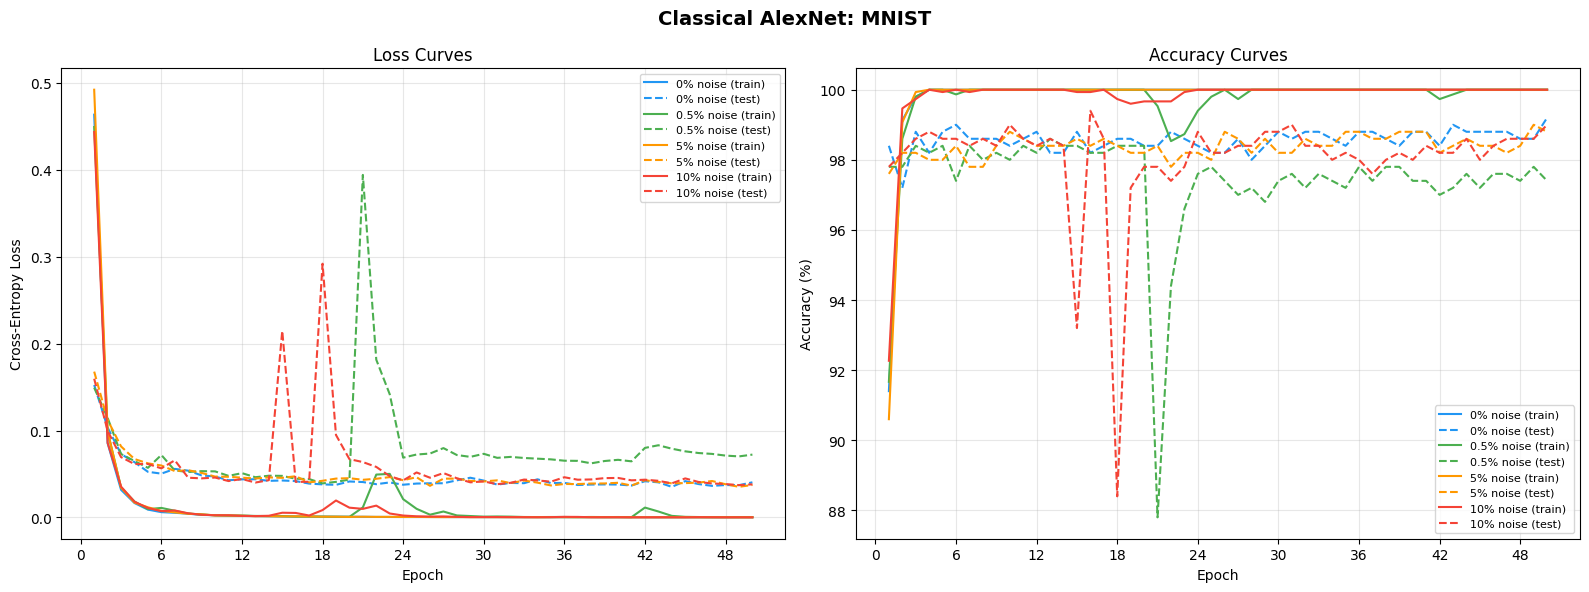

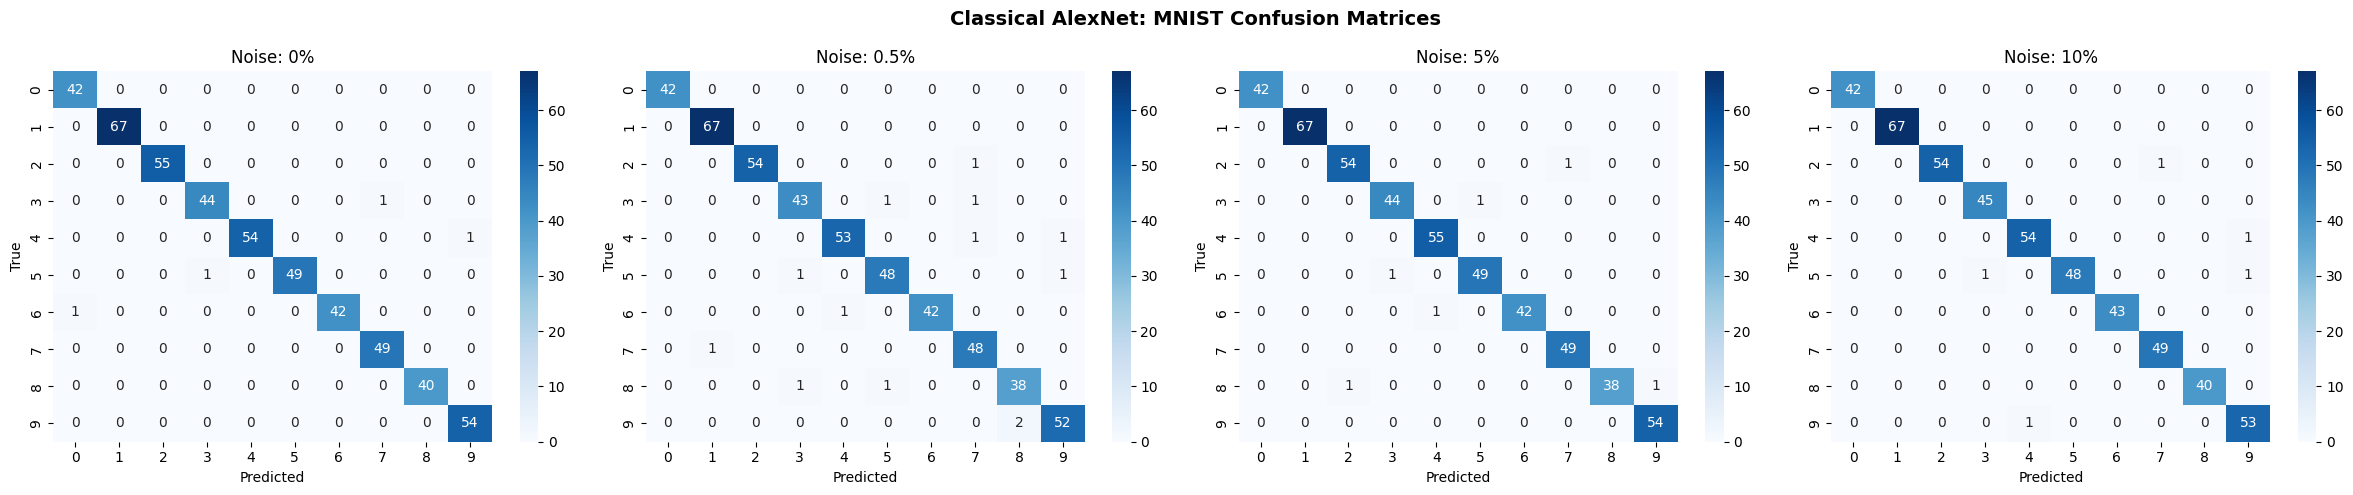


MNIST Classical AlexNet: Results


   Noise   Test Acc    Test Loss    Precision     Recall         F1


      0%     99.20%       0.0404       0.9921     0.9920     0.9920
    0.5%     97.40%       0.0723       0.9742     0.9740     0.9740
      5%     98.80%       0.0374       0.9881     0.9880     0.9880
     10%     99.00%       0.0381       0.9902     0.9900     0.9900




In [12]:
def print_summary(results):
    noise_labels = {0.0: "0%", 0.005: "0.5%", 0.05: "5%", 0.10: "10%"}
    header = f"{'Noise':>8} {'Test Acc':>10} {'Test Loss':>12} {'Precision':>12} {'Recall':>10} {'F1':>10}"
    print("\nMNIST Classical AlexNet: Results")
    print("\n")
    print(header)
    print("\n")
    for noise, history in results.items():
        print(
            f"{noise_labels[noise]:>8} "
            f"{history['test_acc'][-1]*100:>9.2f}% "
            f"{history['test_loss'][-1]:>12.4f} "
            f"{history['precision']:>12.4f} "
            f"{history['recall']:>10.4f} "
            f"{history['f1']:>10.4f}"
        )
    print("\n")

mnist_classes = [str(i) for i in range(10)]
plot_metrics(results)
plot_confusion_matrices(results, mnist_classes)
print_summary(results)